# Análise de Dados - Loterias Caixa
<img src='http://loterias.caixa.gov.br/wps/wcm/connect/c6e414a7-ab65-4a06-b812-745798a9f362/10_Lotofacil.png?MOD=AJPERES&CACHEID=c6e414a7-ab65-4a06-b812-745798a9f362' width=250>

---
### >>> Adição de bibliotecas, download, extração e leitura do arquivo de dados (Pandas DataFrame).

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import io
import requests
from zipfile import ZipFile

%matplotlib inline

arq = requests.get('http://www1.caixa.gov.br/loterias/_arquivos/loterias/D_lotfac.zip')   
ZipFile(io.BytesIO(arq.content)).extractall()
dflis = pd.read_html('d_lotfac.htm', thousands='.', decimal=',') # lista de DataFrames
df = dflis[0] # lista[0] contém o primeiro DataFrame
df

,Concurso,Data Sorteio,Bola1,Bola2,Bola3,Bola4,Bola5,Bola6,Bola7,Bola8,...,Ganhadores_12_Números,Ganhadores_11_Números,Valor_Rateio_15_Números,Valor_Rateio_14_Números,Valor_Rateio_13_Números,Valor_Rateio_12_Números,Valor_Rateio_11_Números,Acumulado_15_Números,Estimativa_Premio,Valor_Acumulado_Especial
0,1,29/09/2003,18,20,25,23,10,11,24,14,...,48807,257593,49765.82,689.84,10.0,4.0,2.0,0.0,0.0,0.00
1,1,29/09/2003,18,20,25,23,10,11,24,14,...,48807,257593,49765.82,689.84,10.0,4.0,2.0,0.0,0.0,0.00
2,1,29/09/2003,18,20,25,23,10,11,24,14,...,48807,257593,49765.82,689.84,10.0,4.0,2.0,0.0,0.0,0.00
3,1,29/09/2003,18,20,25,23,10,11,24,14,...,48807,257593,49765.82,689.84,10.0,4.0,2.0,0.0,0.0,0.00
4,1,29/09/2003,18,20,25,23,10,11,24,14,...,48807,257593,49765.82,689.84,10.0,4.0,2.0,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8372,2060,19/10/2020,22,23,9,17,13,3,14,5,...,165073,855165,1019961.91,1079.44,25.0,10.0,5.0,0.0,1200000.0,9983778.29
8373,2061,20/10/2020,18,20,23,12,21,1,10,2,...,100161,551377,596417.10,1851.29,25.0,10.0,5.0,0.0,1500000.0,10272367.22
8374,2061,20/10/2020,18,20,23,12,21,1,10,2,...,100161,551377,596417.10,1851.29,25.0,10.0,5.0,0.0,1500000.0,10272367.22
8375,2062,21/10/2020,20,6,23,22,15,7,8,24,...,118900,633180,1370413.54,1808.33,25.0,10.0,5.0,0.0,1200000.0,10603918.90


---
### >>> Remove as colunas 'Cidade' e 'UF' e as linhas repetidas.


In [4]:
dfsr = df.drop(columns=['Cidade', 'UF']) # remove as colunas que não se repetem
dfsr.drop_duplicates(inplace = True) # remove as linhas repetidas
dfsr.reset_index(drop = True, inplace = True) # reinicia os índices da tabela
dfsr

,Concurso,Data Sorteio,Bola1,Bola2,Bola3,Bola4,Bola5,Bola6,Bola7,Bola8,...,Ganhadores_12_Números,Ganhadores_11_Números,Valor_Rateio_15_Números,Valor_Rateio_14_Números,Valor_Rateio_13_Números,Valor_Rateio_12_Números,Valor_Rateio_11_Números,Acumulado_15_Números,Estimativa_Premio,Valor_Acumulado_Especial
0,1,29/09/2003,18,20,25,23,10,11,24,14,...,48807,257593,49765.82,689.84,10.0,4.0,2.0,0.0,0.0,0.00
1,2,06/10/2003,23,15,5,4,12,16,20,6,...,81252,478188,596323.70,1388.95,10.0,4.0,2.0,0.0,0.0,0.00
2,3,13/10/2003,20,23,12,8,6,1,7,11,...,96244,608211,400623.70,2173.36,10.0,4.0,2.0,0.0,0.0,0.00
3,4,20/10/2003,16,5,25,24,23,8,12,2,...,123912,706657,902226.02,1498.72,10.0,4.0,2.0,0.0,0.0,0.00
4,5,27/10/2003,15,13,20,2,11,24,9,16,...,195636,860992,380017.55,687.49,10.0,4.0,2.0,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2058,2059,17/10/2020,21,15,12,5,19,17,1,23,...,83694,482559,1180261.05,1850.96,25.0,10.0,5.0,0.0,3700000.0,9550465.31
2059,2060,19/10/2020,22,23,9,17,13,3,14,5,...,165073,855165,1019961.91,1079.44,25.0,10.0,5.0,0.0,1200000.0,9983778.29
2060,2061,20/10/2020,18,20,23,12,21,1,10,2,...,100161,551377,596417.10,1851.29,25.0,10.0,5.0,0.0,1500000.0,10272367.22
2061,2062,21/10/2020,20,6,23,22,15,7,8,24,...,118900,633180,1370413.54,1808.33,25.0,10.0,5.0,0.0,1200000.0,10603918.90


---
### >>> Seleciona apenas as colunas dos números sorteados de cada concurso e calcula a qtde de vezes que cada número foi sorteado. Mostra também os números menos e mais sorteados.
+ #### Na primeira linha, dfsr.iloc[:, 2:17] também pode ser usado.



In [7]:
npdez = dfsr.loc[:, 'Bola1':'Bola15'].to_numpy() # matriz numpy das dezenas sorteadas
qtde_sor = np.array([[n, (npdez == n).sum()] for n in range(1, 26)]) # números e qtdes sorteadas (ou numpy.count_nonzero(df == x))

mi, ma = min(qtde_sor[:, 1]), max(qtde_sor[:, 1])
lmi = qtde_sor[:, 0][(qtde_sor[:, 1] == mi)] # seleciona os números que têm a mesma qtde de mi (qtde mínima).
lma = qtde_sor[:, 0][(qtde_sor[:, 1] == ma)] # o mesmo para a qtde máxima.
print(qtde_sor)
print(f'\nMínimo = {mi} {lmi}\nMáximo = {ma} {lma}')

[[   1 1247]
 [   2 1245]
 [   3 1260]
 [   4 1256]
 [   5 1243]
 [   6 1197]
 [   7 1207]
 [   8 1174]
 [   9 1216]
 [  10 1274]
 [  11 1263]
 [  12 1226]
 [  13 1276]
 [  14 1245]
 [  15 1228]
 [  16 1190]
 [  17 1231]
 [  18 1233]
 [  19 1242]
 [  20 1267]
 [  21 1223]
 [  22 1241]
 [  23 1242]
 [  24 1269]
 [  25 1250]]

Mínimo = 1174 [8]
Máximo = 1276 [13]


---
### >>> Gráfico de barras que mostra a qtde sorteada de cada número (ordem crescente). Destaque para os 15 mais sorteados.

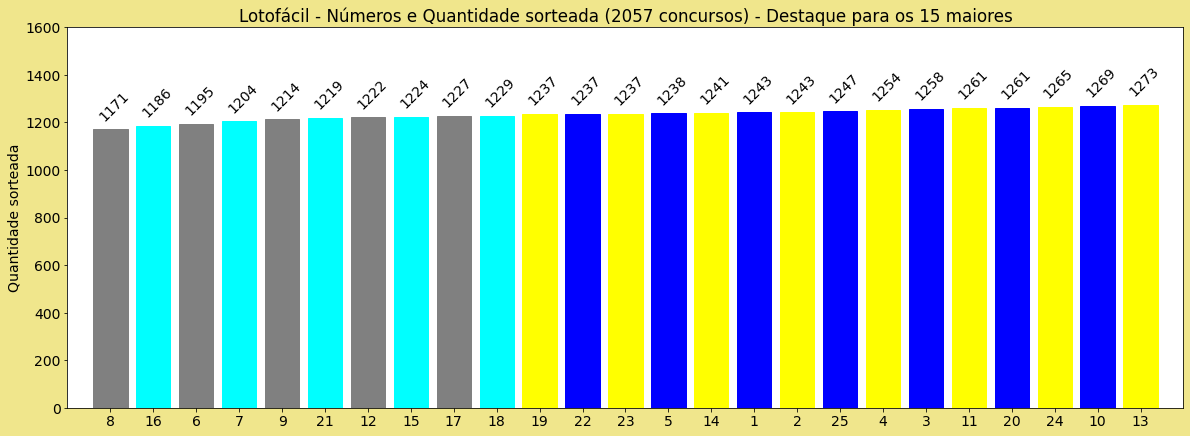

In [4]:
qtde_sor_ord = np.array(sorted(qtde_sor, key=lambda x: x[1])) # ordena os números de acordo com a qtde de sorteios

plt.rcParams['figure.figsize'] = (20, 7) # tamanho da imagem
plt.rcParams['figure.facecolor'] = 'khaki'
plt.rcParams['font.size'] = 14 # tamanho da fonte dos textos
plt.axis([0, 26, 0, 1600]) # intervalo dos eixos x e y

# gráfico de barras horiz. X e Y são listas
barras = plt.bar(range(1, 26), qtde_sor_ord[:, 1], tick_label=qtde_sor_ord[:, 0])

plt.title(f'Lotofácil - Números e Quantidade sorteada ({dfsr.shape[0]} concursos) - Destaque para os 15 maiores') # shape contém qtde de linhas e colunas (tuple)
plt.ylabel('Quantidade sorteada')
for i in range(25):
    cor1, cor2 = 'gray', 'cyan'
    if i >= 10: # cor diferente para os 15 valores com mais frequência nos sorteios
        cor1, cor2 = 'yellow', 'blue'
    barras[i].set_color(cor1 if i % 2 == 0 else cor2)
for i, bar in enumerate(barras):
    plt.text(bar.get_x() + bar.get_width() + 0.1, 1.02 * bar.get_height(), qtde_sor_ord[i, 1],
             ha='right', va='bottom', rotation=45)
plt.show()

---
### >>> Gráfico de 'torta' que mostra a qtde e a porcentagem de prêmios distribuídos por estado (UF).

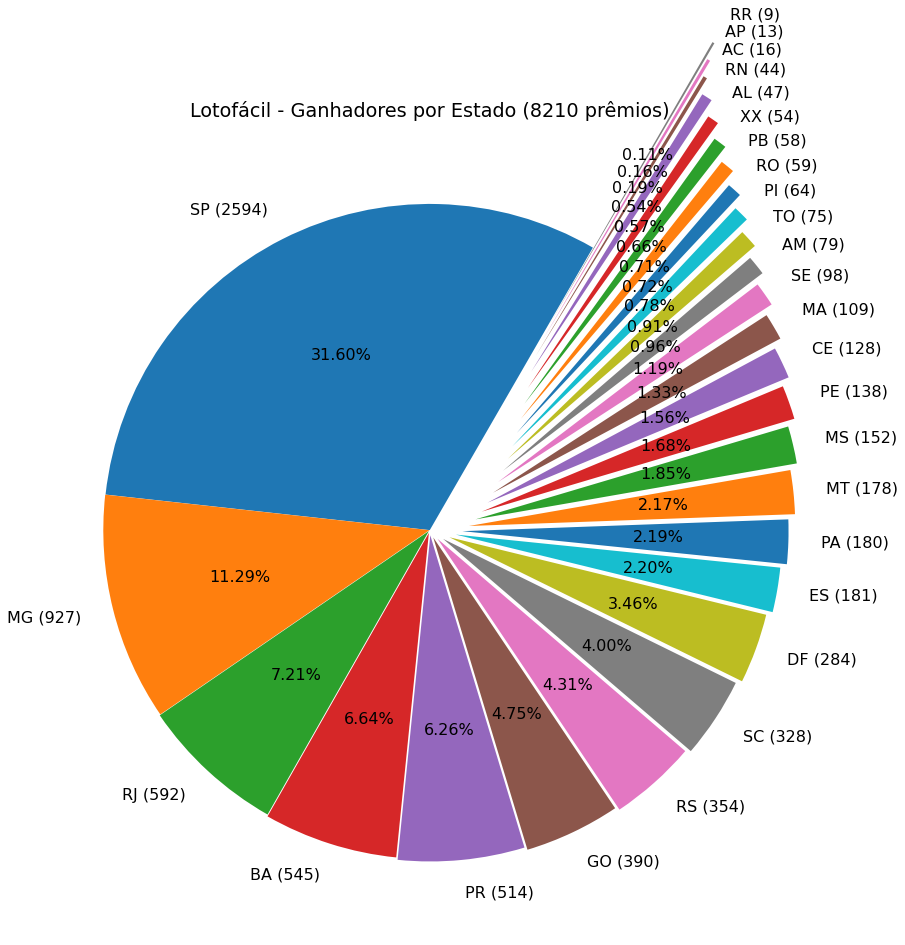

In [6]:
dfuf = df[df['UF'] != '&nbsp']
dfuf_vc = dfuf['UF'].value_counts()
plt.rcParams['figure.figsize'] = (15, 15) # tamanho da imagem
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 16 # tamanho da fonte dos textos
plt.pie(dfuf_vc, [x ** 2 * 0.001 for x in range(len(dfuf_vc))], 
        [dfuf_vc.index[i] + ' (' + str(val) + ')' for i, val in enumerate(dfuf_vc)], 
        autopct='%.2f%%', startangle=60)
plt.title(f'Lotofácil - Ganhadores por Estado ({sum(dfuf_vc)} prêmios)') 
plt.show()